In [3]:
import os

base_dir = "/kaggle/input/datasets/mmagdy908/machine-audio-for-pattern-recognition"

for root, dirs, files in os.walk(base_dir):
    if files:  # only print folders that contain files
        print(root, len(files), "files")

/kaggle/input/datasets/mmagdy908/machine-audio-for-pattern-recognition/Machine 3/machine_data/Normal 14400 files
/kaggle/input/datasets/mmagdy908/machine-audio-for-pattern-recognition/Machine 3/machine_data/Abnormal 3020 files
/kaggle/input/datasets/mmagdy908/machine-audio-for-pattern-recognition/Machine 2/machine_data/Normal 16200 files
/kaggle/input/datasets/mmagdy908/machine-audio-for-pattern-recognition/Machine 2/machine_data/Abnormal 3240 files
/kaggle/input/datasets/mmagdy908/machine-audio-for-pattern-recognition/Machine 1/machine_data/Normal 16200 files
/kaggle/input/datasets/mmagdy908/machine-audio-for-pattern-recognition/Machine 1/machine_data/Abnormal 3176 files


In [ ]:
for f in folders:
    os.makedirs(os.path.join(subset_dir, f), exist_ok=True)


In [ ]:
random.seed(42)  # reproducibility

for f in folders:
    src = os.path.join(base_dir, f)
    dst = os.path.join(subset_dir, f)

    files = os.listdir(src)
    random.shuffle(files)
    selected = files[:3000]  # take first 3000

    for fname in selected:
        shutil.copy(os.path.join(src, fname), os.path.join(dst, fname))


In [13]:
## You can compute features on the fly during training and keep them in RAM (Kaggle gives ~16 GB RAM). This avoids filling disk.


import os, random

random.seed(42)

base_dir = "/kaggle/input/datasets/mmagdy908/machine-audio-for-pattern-recognition"

folders = [
    "Machine 1/machine_data/Normal",
    "Machine 1/machine_data/Abnormal",
    "Machine 2/machine_data/Normal",
    "Machine 2/machine_data/Abnormal",
    "Machine 3/machine_data/Normal",
    "Machine 3/machine_data/Abnormal"
]

subset_paths = {}

for f in folders:
    src = os.path.join(base_dir, f)
    files = os.listdir(src)
    random.shuffle(files)
    selected = files[:3000]
    subset_paths[f] = [os.path.join(src, fname) for fname in selected]

# quick check
for f, paths in subset_paths.items():
    print(f, len(paths))


Machine 1/machine_data/Normal 3000
Machine 1/machine_data/Abnormal 3000
Machine 2/machine_data/Normal 3000
Machine 2/machine_data/Abnormal 3000
Machine 3/machine_data/Normal 3000
Machine 3/machine_data/Abnormal 3000


In [24]:
import librosa
import numpy as np
from scipy.fftpack import dct

class Feature_MFCC:
    def __init__(self, sr=16000, n_mfcc=13, n_filters=40, NFFT=512,
                 frame_size=0.025, frame_stride=0.01, pre_emphasis=0.97,
                 target_duration=9.0, trim_top_db=35):
        """
        Args:
            sr           : Sample rate (Hz)
            n_mfcc       : Number of cepstral coefficients to keep
            n_filters    : Number of Mel filterbank channels
            NFFT         : FFT size
            frame_size   : Frame duration in seconds (25ms standard)
            frame_stride : Frame hop in seconds (10ms standard)
            pre_emphasis : Pre-emphasis filter coefficient (0.97 standard)
        """
        self.sr           = sr
        self.n_mfcc       = n_mfcc
        self.n_filters    = n_filters
        self.NFFT         = NFFT
        self.frame_size   = frame_size
        self.frame_stride = frame_stride
        self.pre_emphasis = pre_emphasis

        # Pre-compute frame lengths in samples (reused across calls)
        self.frame_length = int(round(frame_size * sr))
        self.frame_step   = int(round(frame_stride * sr))

        self.target_len      = int(target_duration * sr)  # 9.0s × 16000 = 144000
        self.trim_top_db     = trim_top_db

     # ── NEW: preprocessing stage ───────────────────────────────────────
    def preprocess(self, y: np.ndarray) -> np.ndarray:
        """
        Step 1 — Trim leading/trailing silence
        Step 2 — Crop or pad to fixed length
        Every file exits this function as exactly (target_len,)
        """
        # Step 1: trim silence from edges
        y_trimmed, _ = librosa.effects.trim(y, top_db=self.trim_top_db)

        # Step 2a: if longer than target, crop from center (not start)
        # Center crop preserves the most representative part of the signal
        if len(y_trimmed) > self.target_len:
            excess = len(y_trimmed) - self.target_len
            start  = excess // 2
            y_out  = y_trimmed[start : start + self.target_len]

        # Step 2b: if shorter than target, pad symmetrically with zeros
        else:
            deficit  = self.target_len - len(y_trimmed)
            pad_left  = deficit // 2
            pad_right = deficit - pad_left
            y_out = np.pad(y_trimmed, (pad_left, pad_right))

        return y_out    # always exactly (target_len,) = (144000,)
    
    def preemphasize(self, y):
        """
        Boost high frequencies to balance the spectrum.
        y[n] = y[n] - alpha * y[n-1]
        """
        y_preemphasized = np.append(y[0], y[1:] - self.pre_emphasis * y[:-1])
        return y_preemphasized
        
    def framing(self, y_preemphasized):
        """
        Slice signal into overlapping frames.

        Returns
        -------
        frames : np.ndarray, shape (num_frames, frame_length)
        """
        
        signal_length = len(y_preemphasized)
        num_frames = int(np.ceil(float(np.abs(signal_length - self.frame_length)) / self.frame_step))
        
        # Pad signal to ensure all frames have equal number of samples
        pad_signal_length = num_frames * self.frame_step + self.frame_length
        z = np.zeros((pad_signal_length - signal_length))
        pad_signal = np.append(y_preemphasized, z)
        
        # Slice the signal into frames
        indices = np.tile(np.arange(0, self.frame_length), (num_frames, 1)) + np.tile(np.arange(0, num_frames * self.frame_step, self.frame_step), (self.frame_length, 1)).T
        frames = pad_signal[indices.astype(np.int32, copy=False)]
        return frames
    def apply_window(self, frames):
        """
        Multiply each frame by a Hamming window to reduce spectral leakage.
        Window is pre-computed once and reused.
        """
        hamming = np.hamming(self.frame_length)  # shape: (frame_length,)
        return frames * hamming                  # broadcast: (num_frames, frame_length)

    
    def fft(self, frames):
        """
        Compute magnitude and power spectrum.
        """
        mag_frames = np.absolute(np.fft.rfft(frames, self.NFFT))  # Magnitude of the FFT
        pow_frames = ((1.0 / self.NFFT) * ((mag_frames) ** 2))  # Power Spectrum
        return mag_frames, pow_frames
    
    def mel_Filterbank(self, pow_frames):
        """
        Apply triangular Mel filterbank and convert to log scale (dB).

        """
        low_freq_mel = 0
        high_freq_mel = 2595 * np.log10(1 + (self.sr / 2) / 700)  # Convert Hz to Mel
        mel_points = np.linspace(low_freq_mel, high_freq_mel, self.n_filters + 2)  # Equally spaced in Mel scale
        hz_points = 700 * (10 ** (mel_points / 2595) - 1)  # Convert Mel to Hz
        bin = np.floor((self.NFFT + 1) * hz_points / self.sr)
        
        fbank = np.zeros((self.n_filters, int(np.floor(self.NFFT / 2 + 1))))
        for m in range(1, self.n_filters + 1):
            f_m_minus = int(bin[m - 1])   # left
            f_m = int(bin[m])             # center
            f_m_plus = int(bin[m + 1])    # right
        
            for k in range(f_m_minus, f_m):
                fbank[m - 1, k] = (k - bin[m - 1]) / (bin[m] - bin[m - 1])
            for k in range(f_m, f_m_plus):
                fbank[m - 1, k] = (bin[m + 1] - k) / (bin[m + 1] - bin[m])
        
        filter_banks = np.dot(pow_frames, fbank.T)
        filter_banks = np.where(filter_banks == 0, np.finfo(float).eps, filter_banks)  # Numerical stability
        filter_banks = 20 * np.log10(filter_banks)  # dB
        return filter_banks
    
    
    def calculate_mfcc(self, filter_banks):
        """
        Apply DCT-II to decorrelate filterbank energies into cepstral coefficients.
        """
        mfcc = dct(filter_banks, type=2, axis=1, norm='ortho')[:, :self.n_mfcc]
        return mfcc
        
    def extract_raw_mfcc(self, file_path: str) -> np.ndarray:
        """
        Returns raw 2D MFCCs (T, n_mfcc) for visualization only.
        Do NOT use this for training — use extract() instead.
        """
        y, _ = librosa.load(file_path, sr=self.sr, mono=True)
        y             = self.preprocess(y)
        y             = self.preemphasize(y)
        frames        = self.framing(y)
        frames        = self.apply_window(frames)
        _, pow_frames = self.fft(frames)
        filter_banks  = self.mel_Filterbank(pow_frames)
        mfcc          = self.calculate_mfcc(filter_banks)   # (T, 13)
        return mfcc
        
    def extract(self, file_path):
        """
        Full pipeline: file → MFCCs aggregated as fixed-size feature vector.

        Returns
        -------
        feature_vector : np.ndarray, shape (n_mfcc * 3,)
            Mean, std, and delta-mean across frames — compact and robust.
        """
        y, _ = librosa.load(file_path, sr=self.sr, mono=True)  # load audioy

        y = self.preprocess(y)

        y_preemphasized = self.preemphasize(y) #preemphasize
        frames = self.framing(y_preemphasized) #calculate the frames
        frames = self.apply_window(frames) # windowing to decrease discontinuities
        mag_frames, pow_frames = self.fft(frames) # FFT
        filter_banks = self.mel_Filterbank(pow_frames)
        mfcc = self.calculate_mfcc(filter_banks)

        # delta and delta-delta
        delta       = np.diff(mfcc,  axis=0)
        delta_delta = np.diff(delta, axis=0)
        
        def summarize(m: np.ndarray) -> np.ndarray:
            return np.concatenate([
                np.mean(m,                    axis=0),
                np.std(m,                     axis=0),
                np.max(m,                     axis=0),
                np.min(m,                     axis=0),
                np.percentile(m, 75, axis=0) - np.percentile(m, 25, axis=0)
            ])

        feature_vec = np.concatenate([
            summarize(mfcc),
            summarize(delta),
            summarize(delta_delta)
        ])                              # always (195,)

        assert feature_vec.shape == (self.n_mfcc * 5 * 3,), \
            f"Bad shape {feature_vec.shape} from {file_path}"

        return feature_vec



Feature vector shape (for SVM): (195,)
Raw MFCC shape (for plotting):  (898, 13)


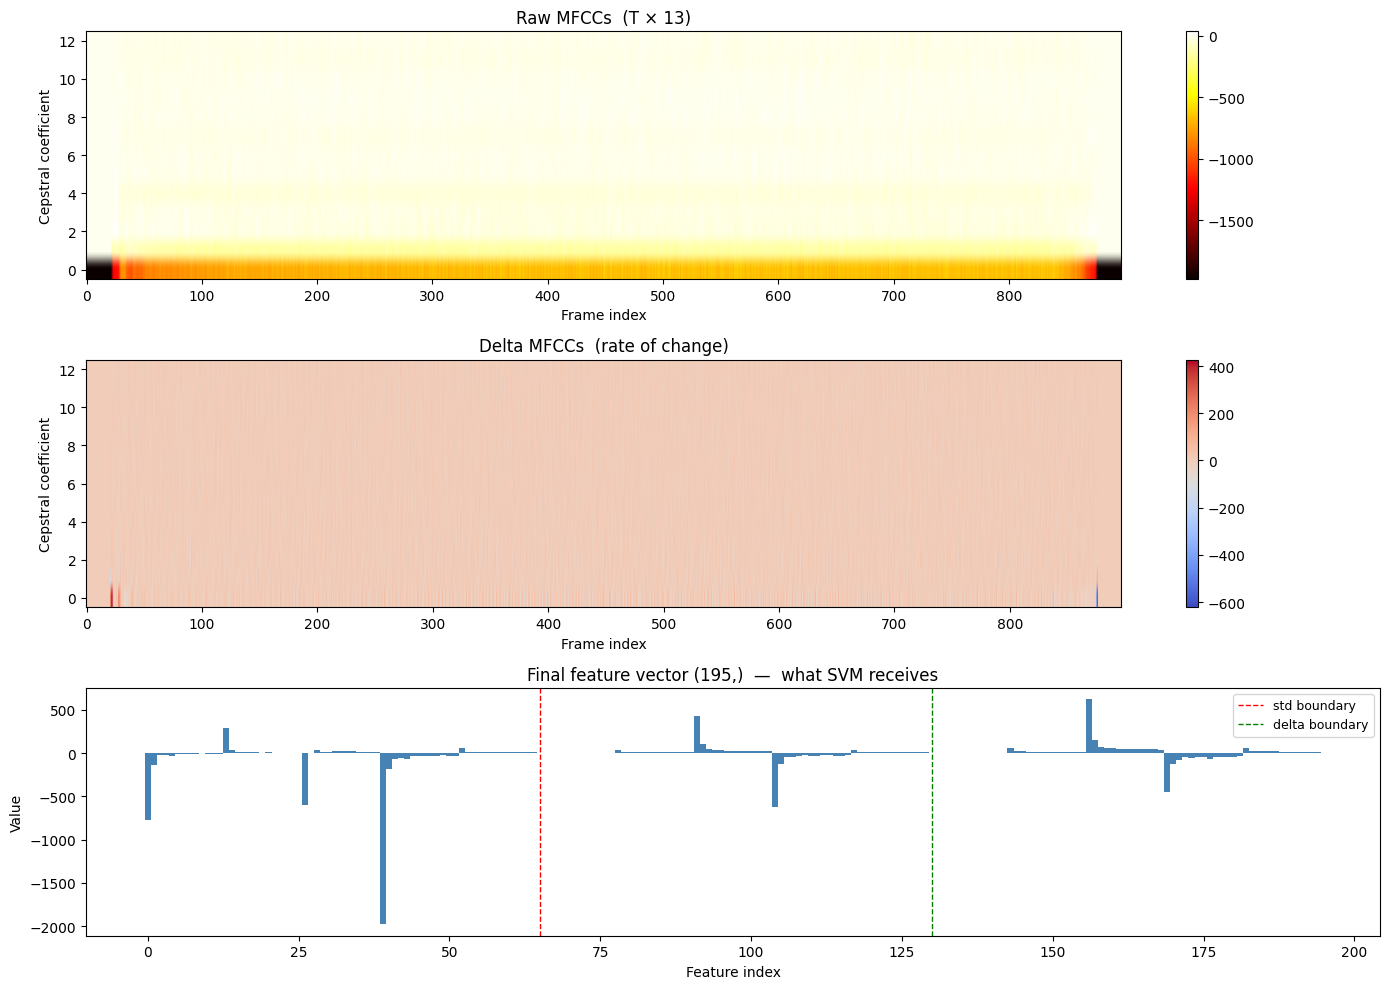

In [25]:
import matplotlib.pyplot as plt
# Example: extract MFCCs for first file in Machine 1 Normal
sample_file = subset_paths["Machine 1/machine_data/Normal"][0]
extractor = Feature_MFCC()

# ── 2. Feature vector for training ─────────────────────────────────────
feature_vec = extractor.extract(sample_file)
print(f"Feature vector shape (for SVM): {feature_vec.shape}")   # (195,)

# ── 3. Raw MFCCs for visualization ─────────────────────────────────────
raw_mfcc = extractor.extract_raw_mfcc(sample_file)
print(f"Raw MFCC shape (for plotting):  {raw_mfcc.shape}")       # (T, 13)

# ── 4. Plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: raw MFCCs heatmap
axes[0].imshow(raw_mfcc.T, cmap='hot', aspect='auto', origin='lower')
axes[0].set_title('Raw MFCCs  (T × 13)')
axes[0].set_xlabel('Frame index')
axes[0].set_ylabel('Cepstral coefficient')
plt.colorbar(axes[0].images[0], ax=axes[0])

# Plot 2: delta
delta = np.diff(raw_mfcc, axis=0)
axes[1].imshow(delta.T, cmap='coolwarm', aspect='auto', origin='lower')
axes[1].set_title('Delta MFCCs  (rate of change)')
axes[1].set_xlabel('Frame index')
axes[1].set_ylabel('Cepstral coefficient')
plt.colorbar(axes[1].images[0], ax=axes[1])

# Plot 3: the final 195-dim feature vector as a bar chart
axes[2].bar(range(len(feature_vec)), feature_vec, color='steelblue', width=1.0)
axes[2].set_title('Final feature vector (195,)  —  what SVM receives')
axes[2].set_xlabel('Feature index')
axes[2].set_ylabel('Value')
axes[2].axvline(x=65,  color='red',   linestyle='--', linewidth=1, label='std boundary')
axes[2].axvline(x=130, color='green', linestyle='--', linewidth=1, label='delta boundary')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Instead of saving MFCCs to disk, you can:

# Keep them in memory (e.g. build a list of numpy arrays).

# Or compute them on the fly inside a PyTorch Dataset class:

from torch.utils.data import Dataset

class AudioDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels

    def __len__(self):
        return len(self.file_paths)

    def __getitemMFCC__(self, idx):
        path = self.file_paths[idx]
        y, sr = librosa.load(path, sr=16000)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=self.n_mfcc)
        return mfcc, self.labels[idx]


In [27]:
# ─────────────────────────────────────────────
# CELL 1 — Imports
# ─────────────────────────────────────────────
import os
import random
import numpy as np
import joblib
from typing import List, Tuple

from scipy.fftpack import dct
import librosa
from tqdm import tqdm                          # progress bar — pip install tqdm

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [28]:
# ─────────────────────────────────────────────
# CELL 3 — Dataset Sampling (your original code, unchanged)
# ─────────────────────────────────────────────
random.seed(42)

base_dir = "/kaggle/input/datasets/mmagdy908/machine-audio-for-pattern-recognition"

# Maps folder path → integer class label 0-5
folder_to_label = {
    "Machine 1/machine_data/Normal"  : 0,   # M1 Normal
    "Machine 1/machine_data/Abnormal": 1,   # M1 Abnormal
    "Machine 2/machine_data/Normal"  : 2,   # M2 Normal
    "Machine 2/machine_data/Abnormal": 3,   # M2 Abnormal
    "Machine 3/machine_data/Normal"  : 4,   # M3 Normal
    "Machine 3/machine_data/Abnormal": 5,   # M3 Abnormal
}

subset_paths = {}
for folder, label in folder_to_label.items():
    src   = os.path.join(base_dir, folder)
    files = [f for f in os.listdir(src) if f.endswith(".wav")]  # wav only
    random.shuffle(files)
    selected = files[:3000]
    subset_paths[folder] = {
        "paths": [os.path.join(src, fname) for fname in selected],
        "label": label
    }

# Sanity check
for folder, data in subset_paths.items():
    print(f"[{data['label']}] {folder:45s} → {len(data['paths'])} files")

[0] Machine 1/machine_data/Normal                 → 3000 files
[1] Machine 1/machine_data/Abnormal               → 3000 files
[2] Machine 2/machine_data/Normal                 → 3000 files
[3] Machine 2/machine_data/Abnormal               → 3000 files
[4] Machine 3/machine_data/Normal                 → 3000 files
[5] Machine 3/machine_data/Abnormal               → 3000 files


In [29]:
# ─────────────────────────────────────────────
# CELL 4 — Feature Extraction Loop (the fully corrected version)
# ─────────────────────────────────────────────
extractor  = Feature_MFCC(sr=16000, n_mfcc=13)

X: List[np.ndarray] = []   # feature vectors, one per audio file
y: List[int]        = []   # integer labels,  one per audio file
skipped             = 0    # count corrupt/unreadable files

for folder, data in subset_paths.items():
    file_paths  = data["paths"]
    class_label = data["label"]

    # tqdm gives a progress bar per class — critical for 18K files
    for file_path in tqdm(file_paths, desc=f"Class {class_label}", unit="file"):
        try:
            feature_vector = extractor.extract(file_path)   # shape (39,)
            X.append(feature_vector)
            y.append(class_label)
        except Exception as e:
            # Log the bad file but DO NOT crash the entire loop
            skipped += 1
            print(f"  [SKIP] {os.path.basename(file_path)} — {e}")

print(f"\nExtraction complete: {len(X)} samples loaded, {skipped} skipped.")

# Convert to numpy — safe because every vector is exactly (39,)
X = np.array(X, dtype=np.float32)   # shape (N, 39)
y = np.array(y, dtype=np.int32)     # shape (N,)

print(f"X shape: {X.shape} | y shape: {y.shape}")
print(f"Class distribution: { {i: int(np.sum(y==i)) for i in range(6)} }")

Class 5: 100%|██████████| 3000/3000 [01:17<00:00, 38.55file/s]


Extraction complete: 18000 samples loaded, 0 skipped.
X shape: (18000, 195) | y shape: (18000,)
Class distribution: {0: 3000, 1: 3000, 2: 3000, 3: 3000, 4: 3000, 5: 3000}


In [30]:
# ─────────────────────────────────────────────
# CELL 5 — Train / Test Split + Scaling
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # ensures each split has balanced class proportions
)

# SVM is distance-based — MUST scale or features with large ranges dominate
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit ONLY on train set
X_test  = scaler.transform(X_test)        # apply same scale to test

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (14400, 195) | Test: (3600, 195)


In [31]:
# ─────────────────────────────────────────────
# CELL 6 — Train SVM
# ─────────────────────────────────────────────
# RBF kernel outperforms linear on audio features.
# class_weight='balanced' handles any minor class imbalance from skipped files.
model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,           # needed if you want confidence scores later
    class_weight='balanced',
    random_state=42
)

print("Training SVM on", X_train.shape[0], "samples...")
model.fit(X_train, y_train)
print("Training complete.")

Training SVM on 14400 samples...
Training complete.


In [32]:
# ─────────────────────────────────────────────
# CELL 7 — Evaluate
# ─────────────────────────────────────────────
CLASS_NAMES = [
    "M1_Normal", "M1_Abnormal",
    "M2_Normal", "M2_Abnormal",
    "M3_Normal", "M3_Abnormal"
]

y_pred = model.predict(X_test)

print("=" * 55)
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

   M1_Normal       0.97      0.99      0.98       600
 M1_Abnormal       0.99      0.97      0.98       600
   M2_Normal       0.98      0.99      0.98       600
 M2_Abnormal       0.99      0.97      0.98       600
   M3_Normal       1.00      1.00      1.00       600
 M3_Abnormal       1.00      1.00      1.00       600

    accuracy                           0.99      3600
   macro avg       0.99      0.99      0.99      3600
weighted avg       0.99      0.99      0.99      3600

Confusion Matrix:
[[595   5   0   0   0   0]
 [ 19 581   0   0   0   0]
 [  0   1 595   4   0   0]
 [  0   0  15 585   0   0]
 [  0   0   0   0 600   0]
 [  0   0   0   0   0 600]]


In [33]:
# ─────────────────────────────────────────────
# CELL 8 — Save model bundle (scaler + model together)
# ─────────────────────────────────────────────
# CRITICAL: Always save the scaler WITH the model.
# If you load the model later without the scaler,
# predictions will be completely wrong.

save_dir = "/kaggle/working"   # this is the only writable directory in Kaggle

bundle = {
    "model"       : model,
    "scaler"      : scaler,
    "extractor_cfg": {           # save config so you can rebuild the extractor
        "sr"       : 16000,
        "n_mfcc"   : 13,
        "n_filters": 40,
        "NFFT"     : 512,
    },
    "class_names" : CLASS_NAMES,
    "label_map"   : {i: name for i, name in enumerate(CLASS_NAMES)}
}

bundle_path = os.path.join(save_dir, "machine_listener_bundle.joblib")
joblib.dump(bundle, bundle_path)
print(f"Model bundle saved → {bundle_path}")

# Verify it loads cleanly before you close the notebook
loaded  = joblib.load(bundle_path)
test_pred = loaded["model"].predict(
    loaded["scaler"].transform(X_test[:5])
)
print("Verification predictions:", [loaded["class_names"][p] for p in test_pred])

Model bundle saved → /kaggle/working/machine_listener_bundle.joblib
Verification predictions: ['M1_Abnormal', 'M1_Abnormal', 'M1_Abnormal', 'M1_Abnormal', 'M1_Abnormal']


In [ ]:
# # In your inference app / infer.py
# import joblib
# import numpy as np

# bundle    = joblib.load("machine_listener_bundle.joblib")
# model     = bundle["model"]
# scaler    = bundle["scaler"]
# cfg       = bundle["extractor_cfg"]
# class_names = bundle["class_names"]

# # Rebuild the extractor with the same config used during training
# extractor = MFCCExtractor(**cfg)

# def predict_audio(file_path: str) -> str:
#     features = extractor.extract(file_path)           # (39,)
#     features = scaler.transform(features.reshape(1, -1))  # (1, 39)
#     label_idx = model.predict(features)[0]
#     confidence = model.predict_proba(features)[0][label_idx]
#     return class_names[label_idx], round(confidence * 100, 2)

# # Usage
# label, conf = predict_audio("test_audio.wav")
# # print(f"Predicted: {label}  ({conf}% confidence)")

In [ ]:
# # predict.py
# # ─────────────────────────────────────────────────────────────
# # Usage:
# #   python predict.py audio.wav
# #   python predict.py /folder/of/wavs/
# # ─────────────────────────────────────────────────────────────

# import os
# import sys
# import time
# import joblib
# import numpy as np
# import librosa
# from scipy.fftpack import dct


# # ── Extractor (must be identical to training) ─────────────────
# class MFCCExtractor:
#     def __init__(self, sr=16000, n_mfcc=13, n_filters=40, NFFT=512,
#                  frame_size=0.025, frame_stride=0.01, pre_emphasis=0.97,
#                  target_duration=9.0, trim_top_db=35):
#         self.sr           = sr
#         self.n_mfcc       = n_mfcc
#         self.n_filters    = n_filters
#         self.NFFT         = NFFT
#         self.frame_length = int(round(frame_size * sr))
#         self.frame_step   = int(round(frame_stride * sr))
#         self.pre_emphasis = pre_emphasis
#         self.target_len   = int(target_duration * sr)
#         self.trim_top_db  = trim_top_db

#     def preprocess(self, y):
#         y_trimmed, _ = librosa.effects.trim(y, top_db=self.trim_top_db)
#         if len(y_trimmed) > self.target_len:
#             excess = len(y_trimmed) - self.target_len
#             start  = excess // 2
#             return y_trimmed[start: start + self.target_len]
#         deficit   = self.target_len - len(y_trimmed)
#         return np.pad(y_trimmed, (deficit // 2, deficit - deficit // 2))

#     def preemphasize(self, y):
#         return np.append(y[0], y[1:] - self.pre_emphasis * y[:-1])

#     def framing(self, y):
#         n         = len(y)
#         n_frames  = 1 + int(np.ceil((n - self.frame_length) / self.frame_step))
#         pad_len   = (n_frames - 1) * self.frame_step + self.frame_length
#         y_padded  = np.pad(y, (0, max(0, pad_len - n)))
#         idx = (np.tile(np.arange(self.frame_length), (n_frames, 1))
#                + np.tile(np.arange(n_frames) * self.frame_step,
#                          (self.frame_length, 1)).T)
#         return y_padded[idx.astype(np.int32)]

#     def apply_window(self, frames):
#         return frames * np.hamming(self.frame_length)

#     def fft(self, frames):
#         mag   = np.absolute(np.fft.rfft(frames, self.NFFT))
#         return mag, (1.0 / self.NFFT) * (mag ** 2)

#     def mel_filterbank(self, pow_frames):
#         high_mel = 2595.0 * np.log10(1.0 + (self.sr / 2.0) / 700.0)
#         mel_pts  = np.linspace(0, high_mel, self.n_filters + 2)
#         hz_pts   = 700.0 * (10.0 ** (mel_pts / 2595.0) - 1.0)
#         bins     = np.floor((self.NFFT + 1) * hz_pts / self.sr).astype(int)
#         fbank    = np.zeros((self.n_filters, self.NFFT // 2 + 1))
#         for m in range(1, self.n_filters + 1):
#             fl, fc, fr = bins[m-1], bins[m], bins[m+1]
#             for k in range(fl, fc):
#                 fbank[m-1, k] = (k - bins[m-1]) / (bins[m] - bins[m-1] + 1e-10)
#             for k in range(fc, fr):
#                 fbank[m-1, k] = (bins[m+1] - k) / (bins[m+1] - bins[m] + 1e-10)
#         fb = np.dot(pow_frames, fbank.T)
#         fb = np.where(fb == 0, np.finfo(float).eps, fb)
#         return 20.0 * np.log10(fb)

#     def calculate_mfcc(self, fb):
#         return dct(fb, type=2, axis=1, norm='ortho')[:, :self.n_mfcc]

#     def summarize(self, m):
#         return np.concatenate([
#             np.mean(m, axis=0), np.std(m, axis=0),
#             np.max(m,  axis=0), np.min(m, axis=0),
#             np.percentile(m, 75, axis=0) - np.percentile(m, 25, axis=0)
#         ])

#     def extract(self, file_path):
#         y, _          = librosa.load(file_path, sr=self.sr, mono=True)
#         y             = self.preprocess(y)
#         y             = self.preemphasize(y)
#         frames        = self.framing(y)
#         frames        = self.apply_window(frames)
#         _, pow_frames = self.fft(frames)
#         fb            = self.mel_filterbank(pow_frames)
#         mfcc          = self.calculate_mfcc(fb)
#         delta         = np.diff(mfcc,  axis=0)
#         delta_delta   = np.diff(delta, axis=0)
#         return np.concatenate([
#             self.summarize(mfcc),
#             self.summarize(delta),
#             self.summarize(delta_delta)
#         ])                                          # (195,)


# # ── Predictor ─────────────────────────────────────────────────
# class MachineListenerPredictor:
#     def __init__(self, bundle_path: str):
#         bundle          = joblib.load(bundle_path)
#         self.model      = bundle["model"]
#         self.scaler     = bundle["scaler"]
#         cfg             = bundle["extractor_cfg"]
#         self.extractor  = MFCCExtractor(**cfg)
#         self.class_names = bundle["class_names"]

#         print(f"Model loaded from: {bundle_path}")
#         print(f"Classes: {self.class_names}")

#     def predict_one(self, file_path: str) -> dict:
#         """
#         Predict the class of a single audio file.
#         Returns label, class index, confidence, and processing time.
#         """
#         t_start = time.perf_counter()

#         features    = self.extractor.extract(file_path)         # (195,)
#         features    = self.scaler.transform(features.reshape(1, -1))  # (1, 195)
#         label_idx   = self.model.predict(features)[0]           # int 0-5
#         proba       = self.model.predict_proba(features)[0]     # (6,)
#         confidence  = proba[label_idx] * 100

#         elapsed = time.perf_counter() - t_start

#         return {
#             "file"      : os.path.basename(file_path),
#             "label_idx" : int(label_idx),
#             "label"     : self.class_names[label_idx],
#             "confidence": round(confidence, 2),
#             "time_sec"  : round(elapsed, 3)
#         }

#     def predict_folder(self, folder_path: str,
#                        results_txt: str = "results.txt",
#                        time_txt:    str = "time.txt"):
#         """
#         Predict all .wav files in a folder in strictly increasing
#         numerical order (1.wav, 2.wav ... 10.wav, 11.wav).
#         Writes results.txt and time.txt in competition format.
#         """
#         # ── strictly increasing numerical sort ────────────────────────
#         wav_files = [f for f in os.listdir(folder_path) if f.endswith(".wav")]
#         wav_files.sort(key=lambda f: int(os.path.splitext(f)[0]))  # "11.wav" → 11
#         # ──────────────────────────────────────────────────────────────

#         if not wav_files:
#             raise FileNotFoundError(f"No .wav files found in {folder_path}")

#         print(f"\nPredicting {len(wav_files)} files in order: "
#               f"{wav_files[0]} → {wav_files[-1]}\n")

#         results, times = [], []

#         for fname in wav_files:
#             full_path = os.path.join(folder_path, fname)
#             out       = self.predict_one(full_path)
#             results.append(out["label_idx"])
#             times.append(out["time_sec"])
#             print(f"  {fname:15s} → [{out['label_idx']}] "
#                   f"{out['label']:15s}  "
#                   f"conf={out['confidence']:5.1f}%  "
#                   f"time={out['time_sec']}s")

#         # ── write competition output files ────────────────────────────
#         with open(results_txt, "w") as f:
#             f.write("\n".join(map(str, results)) + "\n")

#         with open(time_txt, "w") as f:
#             f.write("\n".join(map(str, times)) + "\n")

#         print(f"\nresults.txt → {results_txt}")
#         print(f"time.txt    → {time_txt}")
#         print(f"Total time  : {sum(times):.3f}s  |  "
#               f"Avg per file: {sum(times)/len(times):.3f}s")

#         return results, times


# # ── Entry point ───────────────────────────────────────────────
# if __name__ == "__main__":
#     if len(sys.argv) < 3:
#         print("Usage:")
#         print("  python predict.py machine_listener_bundle.joblib audio.wav")
#         print("  python predict.py machine_listener_bundle.joblib /folder/")
#         sys.exit(1)

#     bundle_path = sys.argv[1]
#     target      = sys.argv[2]
#     predictor   = MachineListenerPredictor(bundle_path)

#     if os.path.isdir(target):
#         predictor.predict_folder(target)
#     else:
#         result = predictor.predict_one(target)
#         print(f"\nFile      : {result['file']}")
#         print(f"Prediction: [{result['label_idx']}] {result['label']}")
#         print(f"Confidence: {result['confidence']}%")
#         print(f"Time      : {result['time_sec']}s")

In [ ]:
# # Run this immediately after downloading the joblib
# # to confirm it works on your machine before the deadline

# predictor = MachineListenerPredictor("machine_listener_bundle.joblib")
# result    = predictor.predict_one("any_test_file.wav")
# print(result)

# # Expected output:
# # {
# #   'file'      : 'test.wav',
# #   'label_idx' : 0,
# #   'label'     : 'M1_Normal',
# #   'confidence': 94.3,
# #   'time_sec'  : 0.187
# # }